In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

In [2]:
sys.path.append(os.path.abspath("../preprocessing"))

from preprocess_churn import load_gold_data

df = load_gold_data()

df.head()

,customer_id,churn,tenure,city_tier,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_from_last_year,coupon_used,order_count,day_since_last_order,cashback_amount,preferred_login_device,preferred_payment_mode,gender,preferred_order_cat,marital_status,tenure_missing_flag,warehouse_to_home_missing_flag,hour_spend_on_app_missing_flag,day_since_last_order_missing_flag,is_new_customer,low_satisfaction_flag,has_complaint,inactive_customer_flag,high_cashback_customer_flag,batch_id,loaded_at,loaded_by
0,50001,1,4.0,3,6.0,3.0,3.0,2,9.0,1,11.0,1.0,1.0,5.0,160.0,mobile phone,debit card,female,laptop & accessory,single,0,0,0,0,1,1,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
1,50002,1,0.0,1,8.0,3.0,4.0,3,7.0,1,15.0,0.0,1.0,0.0,121.0,phone,upi,male,mobile,single,1,0,0,0,1,0,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
2,50003,1,0.0,1,30.0,2.0,4.0,3,6.0,1,14.0,0.0,1.0,3.0,120.0,phone,debit card,male,mobile,single,1,0,0,0,1,0,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
3,50004,1,0.0,3,15.0,2.0,4.0,5,8.0,0,23.0,0.0,1.0,3.0,134.0,phone,debit card,male,laptop & accessory,single,0,0,0,0,1,0,0,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
4,50005,1,0.0,1,12.0,0.0,3.0,5,3.0,0,11.0,1.0,1.0,3.0,130.0,phone,cc,male,mobile,single,0,0,1,0,1,0,0,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user


In [3]:
churned_df = df[df["churn"] == 1].copy()

churned_df.shape

(948, 32)

In [4]:
churned_df["preferred_payment_mode"] = churned_df["preferred_payment_mode"].replace({
    "cod": "cash on delivery",
    "cc": "credit card"
})

churned_df["preferred_login_device"] = churned_df["preferred_login_device"].replace({
    "phone": "mobile phone"
})

In [5]:
cluster_features = [
    "tenure",
    "city_tier",
    "warehouse_to_home",
    "hour_spend_on_app",
    "number_of_device_registered",
    "satisfaction_score",
    "number_of_address",
    "complain",
    "order_amount_hike_from_last_year",
    "coupon_used",
    "order_count",
    "day_since_last_order",
    "cashback_amount",
    "preferred_login_device",
    "preferred_payment_mode",
    "gender",
    "preferred_order_cat",
    "marital_status"
]

X_cluster = churned_df[cluster_features].copy()

X_cluster.head()

,tenure,city_tier,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_from_last_year,coupon_used,order_count,day_since_last_order,cashback_amount,preferred_login_device,preferred_payment_mode,gender,preferred_order_cat,marital_status
0,4.0,3,6.0,3.0,3.0,2,9.0,1,11.0,1.0,1.0,5.0,160.0,mobile phone,debit card,female,laptop & accessory,single
1,0.0,1,8.0,3.0,4.0,3,7.0,1,15.0,0.0,1.0,0.0,121.0,mobile phone,upi,male,mobile,single
2,0.0,1,30.0,2.0,4.0,3,6.0,1,14.0,0.0,1.0,3.0,120.0,mobile phone,debit card,male,mobile,single
3,0.0,3,15.0,2.0,4.0,5,8.0,0,23.0,0.0,1.0,3.0,134.0,mobile phone,debit card,male,laptop & accessory,single
4,0.0,1,12.0,0.0,3.0,5,3.0,0,11.0,1.0,1.0,3.0,130.0,mobile phone,credit card,male,mobile,single


In [6]:
categorical_features = X_cluster.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_cluster.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['preferred_login_device', 'preferred_payment_mode', 'gender', 'preferred_order_cat', 'marital_status']

Numeric features:
['tenure', 'city_tier', 'warehouse_to_home', 'hour_spend_on_app', 'number_of_device_registered', 'satisfaction_score', 'number_of_address', 'complain', 'order_amount_hike_from_last_year', 'coupon_used', 'order_count', 'day_since_last_order', 'cashback_amount']


In [7]:
cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_cluster_processed = cluster_preprocessor.fit_transform(X_cluster)

X_cluster_processed.shape

(948, 31)

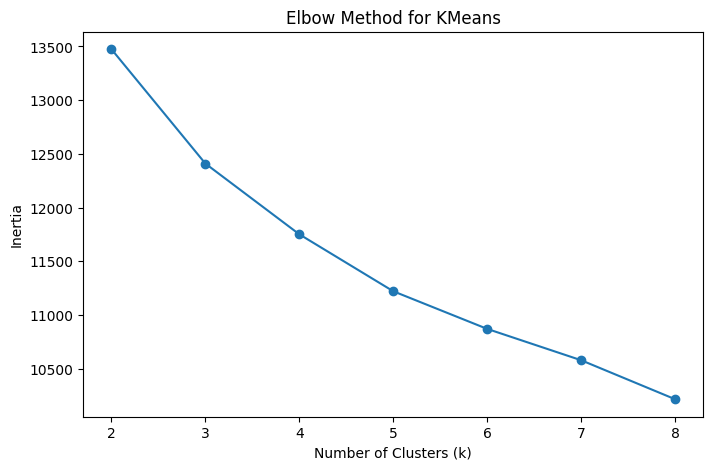

In [8]:
inertia_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_processed)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia_scores, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [9]:
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(X_cluster_processed)
    score = silhouette_score(X_cluster_processed, cluster_labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(K_range),
    "silhouette_score": silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.186913
1,3,0.088415
2,4,0.082793
3,5,0.081655
4,6,0.077518
5,7,0.075596
6,8,0.077671


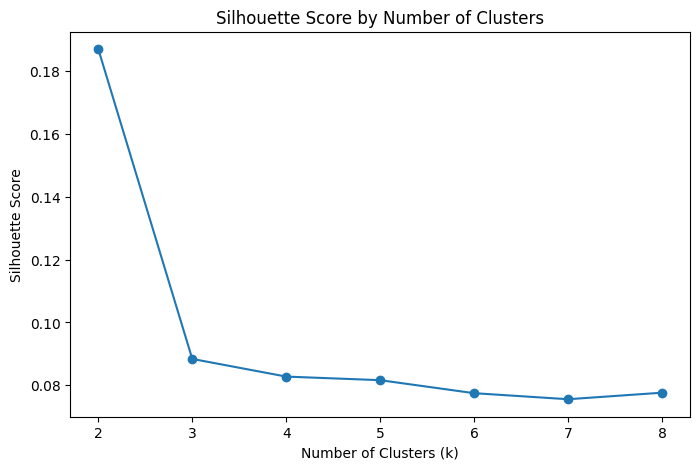

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [11]:
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

churned_df["churn_cluster"] = kmeans_final.fit_predict(X_cluster_processed)

churned_df["churn_cluster"].value_counts().sort_index()

churn_cluster
0    217
1    731
Name: count, dtype: int64

In [12]:
cluster_numeric_profile = churned_df.groupby("churn_cluster")[
    [
        "tenure",
        "warehouse_to_home",
        "hour_spend_on_app",
        "number_of_device_registered",
        "satisfaction_score",
        "number_of_address",
        "complain",
        "order_amount_hike_from_last_year",
        "coupon_used",
        "order_count",
        "day_since_last_order",
        "cashback_amount"
    ]
].mean()

cluster_numeric_profile

,tenure,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_from_last_year,coupon_used,order_count,day_since_last_order,cashback_amount
churn_cluster,,,,,,,,,,,,
0,7.760369,16.543779,2.940092,3.912442,3.036866,4.741935,0.539171,14.258065,3.769585,6.285714,6.281106,201.599078
1,1.704514,15.340629,2.733242,3.941176,3.495212,4.384405,0.534884,15.734610,1.088919,1.726402,2.093023,148.129959


In [13]:
pd.crosstab(
    churned_df["churn_cluster"],
    churned_df["preferred_order_cat"],
    normalize="index"
) * 100

preferred_order_cat,fashion,grocery,laptop & accessory,mobile,mobile phone,others
churn_cluster,,,,,,
0,37.327189,7.373272,26.267281,5.990783,13.824885,9.21659
1,6.429549,0.547196,20.930233,28.317373,43.775650,0.00000


In [14]:
pd.crosstab(
    churned_df["churn_cluster"],
    churned_df["preferred_payment_mode"],
    normalize="index"
) * 100

preferred_payment_mode,cash on delivery,credit card,debit card,e wallet,upi
churn_cluster,,,,,
0,10.138249,26.728111,40.552995,17.050691,5.529954
1,14.500684,26.538988,36.662107,14.090287,8.207934


In [15]:
pd.crosstab(
    churned_df["churn_cluster"],
    churned_df["preferred_login_device"],
    normalize="index"
) * 100

preferred_login_device,computer,mobile phone
churn_cluster,,
0,28.110599,71.889401
1,35.978112,64.021888


In [16]:
pd.crosstab(
    churned_df["churn_cluster"],
    churned_df["marital_status"],
    normalize="index"
) * 100

marital_status,divorced,married,single
churn_cluster,,,
0,17.972350,40.552995,41.474654
1,11.627907,35.020520,53.351573


In [18]:
cluster_name_map = {
    0: "Established High-Value Churned Customers",
    1: "New One-Time Mobile Churned Customers"
}

churned_df["churn_cluster_name"] = churned_df["churn_cluster"].map(cluster_name_map)

churned_df[["customer_id", "churn_cluster", "churn_cluster_name"]].head()

,customer_id,churn_cluster,churn_cluster_name
0,50001,1,New One-Time Mobile Churned Customers
1,50002,1,New One-Time Mobile Churned Customers
2,50003,1,New One-Time Mobile Churned Customers
3,50004,1,New One-Time Mobile Churned Customers
4,50005,1,New One-Time Mobile Churned Customers


In [20]:
os.makedirs("../../05_outputs/segments", exist_ok=True)

churned_df.to_csv(
    "../../05_outputs/segments/churned_user_kmeans_segments.csv",
    index=False
)

os.path.exists("../../05_outputs/segments/churned_user_kmeans_segments.csv")

True

## KMeans Churned User Segmentation Summary

KMeans clustering was applied only to customers who had already churned (`churn == 1`), following the project requirement.

The Elbow Method did not show a very sharp elbow, but the Silhouette Score was highest at `k = 2`. Therefore, two clusters were selected as the final segmentation solution.

### Cluster 0: Established High-Value Churned Customers

This cluster contains 217 customers. These customers have higher tenure, higher order count, higher coupon usage, and higher cashback amount compared with Cluster 1. Their main preferred categories are fashion and laptop & accessory.

This suggests that Cluster 0 represents customers who had stronger previous engagement with the company but still churned. Since they have higher historical value, they may be suitable for win-back campaigns, loyalty comeback offers, and personalized category-based promotions.

### Cluster 1: New One-Time Mobile Churned Customers

This cluster contains 731 customers and represents the majority of churned users. These customers have very low tenure, low order count, lower coupon usage, and lower cashback amount. They are highly concentrated in mobile phone and mobile categories.

This suggests that Cluster 1 represents new or one-time buyers who did not develop repeat purchase behavior. They may be suitable for second-purchase campaigns, mobile accessory cross-sell offers, onboarding journeys, and time-limited vouchers.

### Business Implication

The two clusters require different retention strategies. Cluster 0 should be treated as a win-back and loyalty recovery segment, while Cluster 1 should be treated as an onboarding and second-purchase activation segment.

The clustered churned-user dataset was saved to `05_outputs/segments/churned_user_kmeans_segments.csv`.